
Datos cargados exitosamente. Registros: 506

Modelo LSTM cargado exitosamente
Realizando predicciones...
1/1 [==============================] - 0s 80ms/step

Predicción para las próximas 4 velas (4 horas cada una):
                Fecha    Prediccion
0 2025-03-07 02:00:00  87850.551568
1 2025-03-07 06:00:00  87438.509539
2 2025-03-07 10:00:00  87205.167166
3 2025-03-07 14:00:00  87075.847483


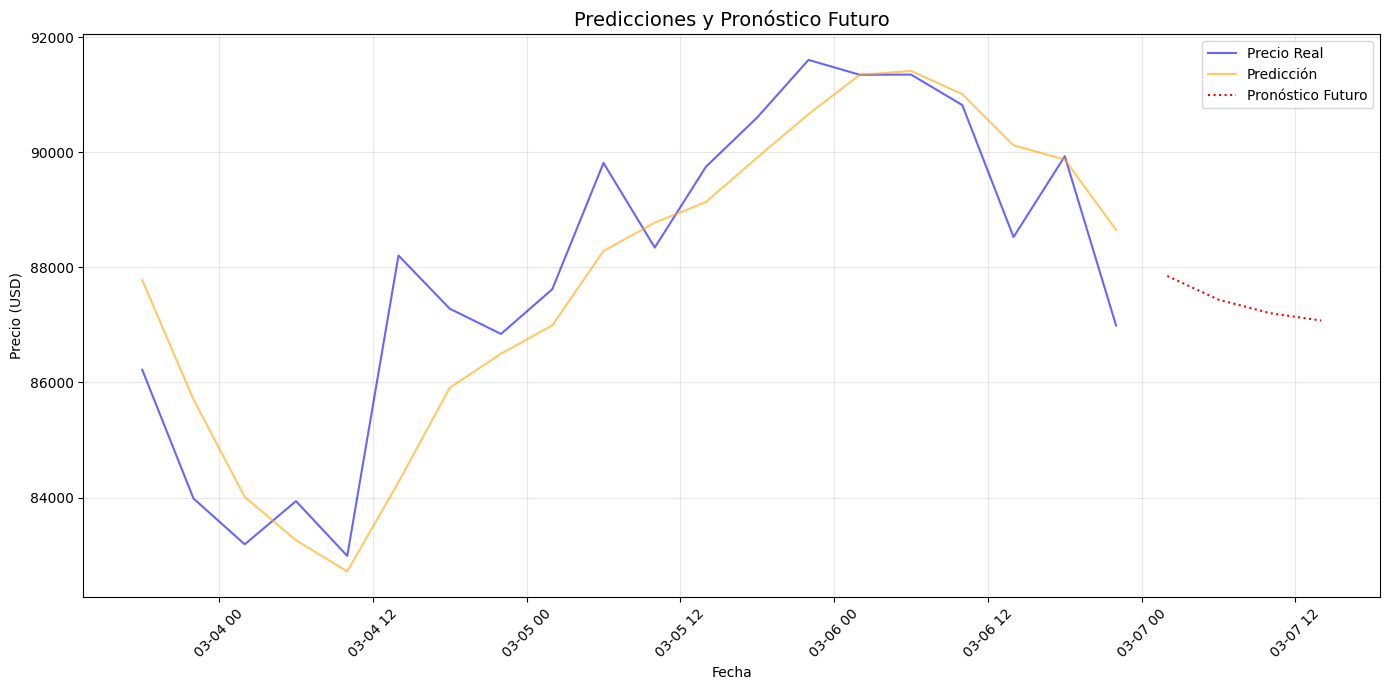


Métricas clave del modelo:
                  Metrica       Valor
0    Error Medio Absoluto  689.719438
1  Error Porcentual Medio    0.716681
2         Precision Total  100.000000

Reporte guardado en: 'reporte_precision_detallado.csv'


In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt

# Paso 1: Configurar rutas de acceso
csv_path = 'D:\iqrobot/btcusdt_data.csv'
model_path = 'D:\YOP\web_page_geosierra\lstm_price_prediction_model.h5'

# Paso 1: Cargar los datos con verificación
try:
    data = pd.read_csv(csv_path)
    print("Datos cargados exitosamente. Registros:", len(data))
except FileNotFoundError:
    raise FileNotFoundError(f"Archivo no encontrado: {csv_path}")

# Validar columnas requeridas
required_columns = ['close', 'datetime']
if not all(col in data.columns for col in required_columns):
    raise ValueError(f"El CSV debe contener: {', '.join(required_columns)}")

# Convertir datetime y ordenar
data['datetime'] = pd.to_datetime(data['datetime'])
data.sort_values('datetime', inplace=True)

# 2. Preprocesamiento de datos
scaler = MinMaxScaler(feature_range=(0, 1))
data_numeric = data.select_dtypes(include=[np.number])
data_scaled = scaler.fit_transform(data_numeric)

# 3. Creación de secuencias completas
def create_sequences_full(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size, 0])  # 'close' es la primera columna
    return np.array(X), np.array(y)

seq_length = 50  # Asegurar que coincida con el modelo entrenado
X_full, y_full = create_sequences_full(data_scaled, seq_length)
X_full = X_full.reshape((X_full.shape[0], seq_length, data_numeric.shape[1]))

# 4. Carga del modelo
try:
    model = load_model(model_path)
    print("Modelo LSTM cargado exitosamente")
except Exception as e:
    raise ValueError(f"Error cargando el modelo: {str(e)}")

# 5. Predicción de todas las velas
print("Realizando predicciones...")
y_pred_scaled = model.predict(X_full)

# 6. Inversión de normalización
def inverse_transform(scaler, data, col_index=0):
    dummy = np.zeros((len(data), data_numeric.shape[1]))
    dummy[:, col_index] = data
    return scaler.inverse_transform(dummy)[:, col_index]

y_real = inverse_transform(scaler, y_full)
y_pred = inverse_transform(scaler, y_pred_scaled.ravel())

# 7. Creación del DataFrame de resultados
predictions_df = pd.DataFrame({
    'Fecha': data['datetime'].iloc[seq_length:].values,
    'Real': y_real,
    'Prediccion': y_pred
})

# 8. Cálculo de métricas de precisión
error_threshold = 0.2  # Definir umbral de error
predictions_df['Error_Absoluto'] = np.abs(predictions_df['Real'] - predictions_df['Prediccion'])
predictions_df['Error_Porcentual'] = (predictions_df['Error_Absoluto'] / predictions_df['Real']) * 100
predictions_df['Acerto'] = predictions_df['Error_Porcentual'] <= (error_threshold * 100)

# 9. Predicción de las próximas 4 velas
last_sequence = data_scaled[-seq_length:]
future_predictions = []

for _ in range(4):
    input_seq = last_sequence.reshape(1, seq_length, data_numeric.shape[1])
    pred = model.predict(input_seq)[0, 0]
    pred = np.clip(pred, 0, 1)  # Asegurar valores entre 0 y 1
    
    # Crear nueva secuencia
    new_row = np.hstack((pred, last_sequence[-1, 1:]))
    last_sequence = np.vstack([last_sequence[1:], new_row])
    future_predictions.append(pred)

# Inversión de normalización
future_prices = inverse_transform(scaler, np.array(future_predictions))

# Resultado de predicción futura
future_dates = pd.date_range(start=data['datetime'].iloc[-1], periods=5, freq='4H')[1:]
future_df = pd.DataFrame({
    'Fecha': future_dates,
    'Prediccion': future_prices
})

print("\nPredicción para las próximas 4 velas (4 horas cada una):")
print(future_df)

# 10. Visualización gráfica de las últimas 20 velas + pronóstico
plt.figure(figsize=(14, 7))
plt.plot(predictions_df['Fecha'].iloc[-20:], predictions_df['Real'].iloc[-20:], label='Precio Real', color='blue', alpha=0.6)
plt.plot(predictions_df['Fecha'].iloc[-20:], predictions_df['Prediccion'].iloc[-20:], label='Predicción', color='orange', alpha=0.6)
plt.plot(future_df['Fecha'], future_df['Prediccion'], label='Pronóstico Futuro', color='red', linestyle='dotted')

plt.title('Predicciones y Pronóstico Futuro', fontsize=14)
plt.xlabel('Fecha')
plt.ylabel('Precio (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 11. DataFrame de métricas clave
metricas_df = pd.DataFrame({
    'Metrica': ['Error Medio Absoluto', 'Error Porcentual Medio', 'Precision Total'],
    'Valor': [
        predictions_df['Error_Absoluto'].mean(),
        predictions_df['Error_Porcentual'].mean(),
        (predictions_df['Acerto'].sum() / len(predictions_df)) * 100
    ]
})

print("\nMétricas clave del modelo:")
print(metricas_df)

# Guardar resultados
predictions_df.to_csv('reporte_precision_detallado.csv', index=False)
print("\nReporte guardado en: 'reporte_precision_detallado.csv'")
